In [2]:
import pandas as pd
movie=pd.read_excel(r"C:\\Users\\PAUL\\Documents\\final_movie_data.xlsx")
movie.head()


,userId,movieId,rating,timestamp,adult,belongs_to_collection,budget,genres,homepage,imdb_id,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,1,1371,2.5,1260759135,False,"{'id': 1575, 'name': 'Rocky Collection', 'post...",17000000,"[{'id': 18, 'name': 'Drama'}]",NaN,tt0084602,...,1982-05-28,270000000,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The greatest challenge.,Rocky III,False,6.6,894
1,1,1405,1.0,1260759203,False,NaN,546883,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",NaN,tt0015881,...,1924-12-04,0,140.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Greed,False,7.5,25
2,1,2105,4.0,1260759139,False,"{'id': 2806, 'name': 'American Pie Collection'...",11000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,tt0163651,...,1999-07-09,235483004,95.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,There's nothing like your first piece.,American Pie,False,6.4,2358
3,1,2193,2.0,1260759198,False,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",http://www.crownintlpictures.com/lntitles.html,tt0085980,...,1983-03-04,22587000,97.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,School's out...But Bobby's education has just ...,My Tutor,False,5.8,17
4,1,2294,2.0,1260759108,False,NaN,22000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt0261392,...,2001-08-22,33788161,104.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Hollywood had it coming,Jay and Silent Bob Strike Back,False,6.4,491


In [3]:
movie.drop(columns=["title","production_companies","production_countries","adult","belongs_to_collection","poster_path","homepage","imdb_id","original_language","original_title","overview","spoken_languages","status","tagline","video"],inplace=True,errors="ignore")
movie.tail()

,userId,movieId,rating,timestamp,budget,genres,popularity,release_date,revenue,runtime,vote_average,vote_count
44989,671,4995,4.0,1064891537,15000000,"[{'id': 18, 'name': 'Drama'}]",7.595679,1997-09-11,43101594,155.0,7.5,812
44990,671,5816,4.0,1065111963,0,"[{'id': 35, 'name': 'Comedy'}]",4.714910,2006-09-28,0,95.0,6.3,8
44991,671,5902,3.5,1064245507,22000000,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",7.719173,1977-06-15,50750000,175.0,7.0,210
44992,671,5991,4.5,1064245387,0,"[{'id': 18, 'name': 'Drama'}]",3.553763,1924-12-23,0,90.0,7.7,63
44993,671,5995,4.0,1066793014,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",0.768593,2003-07-31,0,105.0,4.0,5


In [ ]:
import ast
#hot-encoding to split the list of genres into separate columns
movie['genres'] = movie['genres'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])
movie['genres_list'] = movie['genres'].apply(lambda x: [i['name'] for i in x])
genres_dummies = movie['genres_list'].explode().str.get_dummies().groupby(level=0).sum()
movie_final = pd.concat([movie, genres_dummies], axis=1)
movie_final = movie_final.drop(['genres', 'genres_list'], axis=1)
movie_final.head()


,userId,movieId,rating,timestamp,budget,popularity,release_date,revenue,runtime,vote_average,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,1371,2.5,1260759135,17000000,11.673366,1982-05-28,270000000,99.0,6.6,...,0,0,0,0,0,0,0,0,0,0
1,1,1405,1.0,1260759203,546883,6.925081,1924-12-04,0,140.0,7.5,...,1,0,0,0,0,0,0,0,0,0
2,1,2105,4.0,1260759139,11000000,18.344227,1999-07-09,235483004,95.0,6.4,...,0,0,0,0,1,0,0,0,0,0
3,1,2193,2.0,1260759198,0,4.675460,1983-03-04,22587000,97.0,5.8,...,0,0,0,0,1,0,0,0,0,0
4,1,2294,2.0,1260759108,22000000,11.619446,2001-08-22,33788161,104.0,6.4,...,0,0,0,0,0,0,0,0,0,0


In [5]:
movie_final.dropna(inplace=True)
movie_final.tail()

,userId,movieId,rating,timestamp,budget,popularity,release_date,revenue,runtime,vote_average,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
44989,671,4995,4.0,1064891537,15000000,7.595679,1997-09-11,43101594,155.0,7.5,...,0,0,0,0,0,0,0,0,0,0
44990,671,5816,4.0,1065111963,0,4.714910,2006-09-28,0,95.0,6.3,...,0,0,0,0,0,0,0,0,0,0
44991,671,5902,3.5,1064245507,22000000,7.719173,1977-06-15,50750000,175.0,7.0,...,1,0,0,0,0,0,0,0,1,0
44992,671,5991,4.5,1064245387,0,3.553763,1924-12-23,0,90.0,7.7,...,0,0,0,0,0,0,0,0,0,0
44993,671,5995,4.0,1066793014,0,0.768593,2003-07-31,0,105.0,4.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
movie_final['budget'] = movie_final['budget'].replace(0, np.nan)
movie_final['revenue'] = movie_final['revenue'].replace(0, np.nan)
movie_final_clean = movie_final.dropna(subset=['budget', 'revenue',])
movie_final_clean.head()

,userId,movieId,rating,timestamp,budget,popularity,release_date,revenue,runtime,vote_average,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,1,1371,2.5,1260759135,17000000.0,11.673366,1982-05-28,270000000.0,99.0,6.6,...,0,0,0,0,0,0,0,0,0,0
2,1,2105,4.0,1260759139,11000000.0,18.344227,1999-07-09,235483004.0,95.0,6.4,...,0,0,0,0,1,0,0,0,0,0
4,1,2294,2.0,1260759108,22000000.0,11.619446,2001-08-22,33788161.0,104.0,6.4,...,0,0,0,0,0,0,0,0,0,0
7,2,62,3.0,835355749,10500000.0,22.494622,1968-04-10,68700000.0,149.0,7.9,...,0,0,0,1,0,1,0,0,0,0
9,2,144,3.0,835356016,2500000.0,6.357321,1987-01-01,3200000.0,128.0,7.5,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
# 1. Runtime: Fix the zeros
movie_final_clean['runtime'] = movie_final_clean['runtime'].replace(0, movie_final_clean['runtime'].median())
# 2. Release Date: Get the Year
movie_final_clean['release_date'] = pd.to_datetime(movie_final_clean['release_date'], errors='coerce')
movie_final_clean['release_year'] = movie_final_clean['release_date'].dt.year
# 3. Timestamp: Get the Hour or Day of Week
movie_final_clean['rating_datetime'] = pd.to_datetime(movie_final_clean['timestamp'], unit='s')
movie_final_clean['day_of_week'] = movie_final_clean['rating_datetime'].dt.dayofweek # 0=Monday, 6=Sunday
movie_final_clean['hour_of_day'] = movie_final_clean['rating_datetime'].dt.hour
movie_final_clean.head()


,userId,movieId,rating,timestamp,budget,popularity,release_date,revenue,runtime,vote_average,...,Romance,Science Fiction,TV Movie,Thriller,War,Western,release_year,rating_datetime,day_of_week,hour_of_day
0,1,1371,2.5,1260759135,17000000.0,11.673366,1982-05-28,270000000.0,99.0,6.6,...,0,0,0,0,0,0,1982,2009-12-14 02:52:15,0,2
2,1,2105,4.0,1260759139,11000000.0,18.344227,1999-07-09,235483004.0,95.0,6.4,...,1,0,0,0,0,0,1999,2009-12-14 02:52:19,0,2
4,1,2294,2.0,1260759108,22000000.0,11.619446,2001-08-22,33788161.0,104.0,6.4,...,0,0,0,0,0,0,2001,2009-12-14 02:51:48,0,2
7,2,62,3.0,835355749,10500000.0,22.494622,1968-04-10,68700000.0,149.0,7.9,...,0,1,0,0,0,0,1968,1996-06-21 11:15:49,4,11
9,2,144,3.0,835356016,2500000.0,6.357321,1987-01-01,3200000.0,128.0,7.5,...,1,0,0,0,0,0,1987,1996-06-21 11:20:16,4,11


In [ ]:
import pandas as pd
# 1. Calculate the average rating for every unique UserID
# By creating a 'dictionary' where the index is the UserID and the value is their average
user_means = movie_final_clean.groupby('userId')['rating'].mean()
# 2. Map those averages back to your original dataframe
movie_final_clean['user_mean_rating'] = movie_final_clean['userId'].map(user_means)
# 3. Calculating the number of movies each user has rated
user_counts = movie_final_clean.groupby('userId')['rating'].count()
movie_final_clean['user_rating_count'] = movie_final_clean['userId'].map(user_counts)
movie_final_clean.head(10)

,userId,movieId,rating,timestamp,budget,popularity,release_date,revenue,runtime,vote_average,...,War,Western,release_year,rating_datetime,day_of_week,hour_of_day,user_mean_rating,user_rating_count,budget_log,revenue_log
0,1,1371,2.5,1260759135,17000000.0,11.673366,1982-05-28,270000000.0,99.0,6.6,...,0,0,1982,2009-12-14 02:52:15,0,2,2.833333,3,16.648724,19.413933
2,1,2105,4.0,1260759139,11000000.0,18.344227,1999-07-09,235483004.0,95.0,6.4,...,0,0,1999,2009-12-14 02:52:19,0,2,2.833333,3,16.213406,19.277149
4,1,2294,2.0,1260759108,22000000.0,11.619446,2001-08-22,33788161.0,104.0,6.4,...,0,0,2001,2009-12-14 02:51:48,0,2,2.833333,3,16.906553,17.335621
7,2,62,3.0,835355749,10500000.0,22.494622,1968-04-10,68700000.0,149.0,7.9,...,0,0,1968,1996-06-21 11:15:49,4,11,3.450000,40,16.166886,18.045260
9,2,144,3.0,835356016,2500000.0,6.357321,1987-01-01,3200000.0,128.0,7.5,...,0,0,1987,1996-06-21 11:20:16,4,11,3.450000,40,14.731802,14.978662
10,2,150,5.0,835355395,12000000.0,15.297121,1982-12-07,78868508.0,96.0,6.5,...,0,0,1982,1996-06-21 11:09:55,4,11,3.450000,40,16.300417,18.183293
11,2,153,4.0,835355441,4000000.0,11.609441,2003-08-31,119723856.0,102.0,7.3,...,0,0,2003,1996-06-21 11:10:41,4,11,3.450000,40,15.201805,18.600698
12,2,161,3.0,835355493,85000000.0,12.114932,2001-12-07,450717150.0,116.0,7.2,...,0,0,2001,1996-06-21 11:11:33,4,11,3.450000,40,18.258162,19.926351
13,2,165,3.0,835355441,40000000.0,13.689855,1989-11-20,332000000.0,108.0,7.4,...,0,0,1989,1996-06-21 11:10:41,4,11,3.450000,40,17.504390,19.620646
14,2,168,3.0,835355710,24000000.0,12.596956,1986-11-25,133000000.0,119.0,6.9,...,0,0,1986,1996-06-21 11:15:10,4,11,3.450000,40,16.993564,18.705860


In [ ]:
import numpy as np
import pandas as pd
# 2. Applying the Log Transformation to cater for the differences in scale and to reduce skewness
movie_final_clean['budget_log'] = np.log1p(movie_final_clean['budget'])
movie_final_clean['revenue_log'] = np.log1p(movie_final_clean['revenue'])
print(movie_final_clean[['budget', 'budget_log', 'revenue', 'revenue_log']].head())

       budget  budget_log      revenue  revenue_log
0  17000000.0   16.648724  270000000.0    19.413933
2  11000000.0   16.213406  235483004.0    19.277149
4  22000000.0   16.906553   33788161.0    17.335621
7  10500000.0   16.166886   68700000.0    18.045260
9   2500000.0   14.731802    3200000.0    14.978662


In [10]:
movie_final_clean.info()

<class 'pandas.DataFrame'>
Index: 21728 entries, 0 to 44991
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   userId             21728 non-null  int64         
 1   movieId            21728 non-null  int64         
 2   rating             21728 non-null  float64       
 3   timestamp          21728 non-null  int64         
 4   budget             21728 non-null  float64       
 5   popularity         21728 non-null  float64       
 6   release_date       21728 non-null  datetime64[us]
 7   revenue            21728 non-null  float64       
 8   runtime            21728 non-null  float64       
 9   vote_average       21728 non-null  float64       
 10  vote_count         21728 non-null  int64         
 11  Action             21728 non-null  int64         
 12  Adventure          21728 non-null  int64         
 13  Animation          21728 non-null  int64         
 14  Comedy             217

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# 1. Feature Selection (Numbers & One-Hot Genres)
# Using the log-transformed budget and revenue and the user's mean rating
X = pd.concat([
    movie_final_clean[['budget_log', 'revenue_log', 'popularity', 'runtime',
                       'vote_average', 'vote_count', 'user_mean_rating']],
    genres_dummies.loc[movie_final_clean.index]
], axis=1)
y = movie_final_clean['rating']
# 2. Splitting into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 3. Creating the Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# 4. Training the Model
rf_model.fit(X_train, y_train)
# 5. Prediction and Evaluation
y_pred = rf_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

Mean Squared Error: 0.8269739857407271


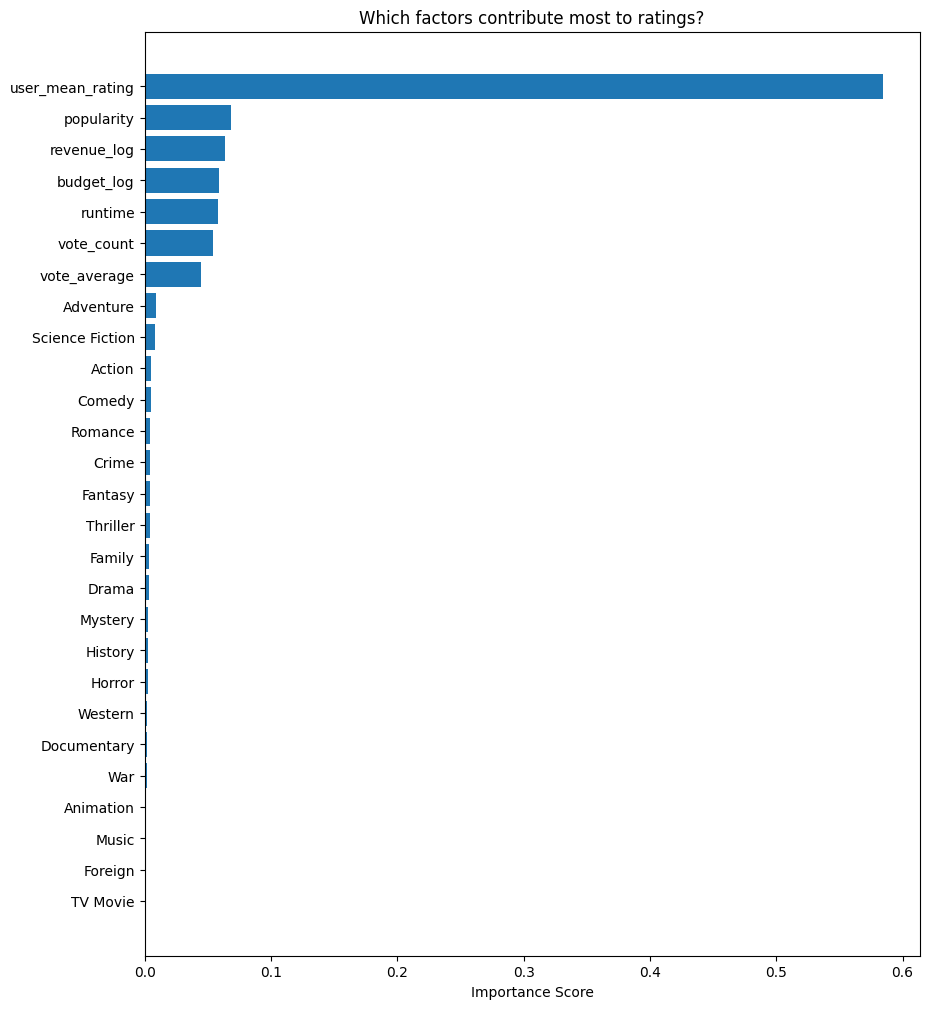

             Feature  Importance
6   user_mean_rating    0.584296
2         popularity    0.068738
1        revenue_log    0.063567
0         budget_log    0.058527
3            runtime    0.058377
5         vote_count    0.054466
4       vote_average    0.044645
8          Adventure    0.009119
22   Science Fiction    0.008610
7             Action    0.004963
10            Comedy    0.004938
21           Romance    0.004452
11             Crime    0.004315
15           Fantasy    0.004091
24          Thriller    0.003959
14            Family    0.003830
13             Drama    0.003653
20           Mystery    0.002878
17           History    0.002725
18            Horror    0.002514
26           Western    0.001631
12       Documentary    0.001622
25               War    0.001524
9          Animation    0.001483
19             Music    0.001077
16           Foreign    0.000000
23          TV Movie    0.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# 1. Getting the importance scores from your trained model
importances = rf_model.feature_importances_
# 2. Matching them with your column names
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# 3. Sorting them from highest to lowest
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# 4. Plotting the top 10 to see it visually
plt.figure(figsize=(10, 12))
plt.barh(feature_importance_df['Feature'].head(1000), feature_importance_df['Importance'].head(1000))
plt.xlabel('Importance Score')
plt.title('Which factors contribute most to ratings?')
plt.gca().invert_yaxis() 
plt.show()
print(feature_importance_df.head(1000))

In [22]:
movie_final_clean.to_csv('C:\\Users\\PAUL\\Documents\\movie_final_clean_data.csv', index=False)
